In [1]:
!pip install torch torchvision torchaudio
!pip install transformers==4.41.2
!pip install hdbscan

!pip install pandas numpy tqdm
!pip install scikit-learn

In [2]:
import sys
print(sys.version)


3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


CUDA available: False
GPU name: None


In [4]:
'''!pip install --upgrade pip
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121'''


'!pip install --upgrade pip\n!pip uninstall -y torch torchvision torchaudio\n!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121'

In [5]:
!git clone https://github.com/logpai/loghub.git


fatal: destination path 'loghub' already exists and is not an empty directory.


# importing the whole log file

In [6]:
#!wget -O BGL.tar.gz "https://zenodo.org/records/14767417/files/BGL.tar.gz?download=1"

In [7]:
'''import tarfile

file_path = "BGL.tar.gz"
with tarfile.open(file_path, "r:gz") as tar:
    tar.extractall()   # Extracts files to current directory
    '''

'import tarfile\n\nfile_path = "BGL.tar.gz"\nwith tarfile.open(file_path, "r:gz") as tar:\n    tar.extractall()   # Extracts files to current directory\n    '

In [8]:
#!head -n 10 BGL.log

In [9]:
#!head -n 2000 BGL.log > BGL_2000.log

## imporitng the file **BGL.log** or **BGL_50000.log** or **loghub/BGL/BGL_2k.log**

In [10]:
import os

bgl_path = "loghub/BGL/BGL_2k.log"
#bgl_path = "BGL_50000.log"
print("File exists:", os.path.exists(bgl_path))

File exists: True


In [11]:
with open(bgl_path) as f:
    for i in range(5):
        print(f.readline())


- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.50.675872 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected

- 1117838573 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.42.53.276129 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected

- 1117838976 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.49.36.156884 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected

- 1117838978 2005.06.03 R02-M1-N0-C:J12-U11 2005-06-03-15.49.38.026704 R02-M1-N0-C:J12-U11 RAS KERNEL INFO instruction cache parity error corrected

- 1117842440 2005.06.03 R23-M0-NE-C:J05-U01 2005-06-03-16.47.20.730545 R23-M0-NE-C:J05-U01 RAS KERNEL INFO 63543 double-hummer alignment exceptions



In [12]:
import re

def preprocess_bgl(line):
    parts = line.strip().split()

    label = parts[0]                 # "-" or anomaly label
    node = parts[3]                  # R02-M1-N0-C:J12-U11
    message = " ".join(parts[9:])    # actual log message

    # normalize numbers
    message = re.sub(r"\b\d+\b", "<NUM>", message)

    return label, node, message


In [13]:
with open(bgl_path) as f:
    for _ in range(50):
        line = f.readline()
        label, node, msg = preprocess_bgl(line)
        print("LABEL:", label)
        print("NODE :", node)
        print("MSG  :", msg)
        print("-" * 40)


LABEL: -
NODE : R02-M1-N0-C:J12-U11
MSG  : instruction cache parity error corrected
----------------------------------------
LABEL: -
NODE : R02-M1-N0-C:J12-U11
MSG  : instruction cache parity error corrected
----------------------------------------
LABEL: -
NODE : R02-M1-N0-C:J12-U11
MSG  : instruction cache parity error corrected
----------------------------------------
LABEL: -
NODE : R02-M1-N0-C:J12-U11
MSG  : instruction cache parity error corrected
----------------------------------------
LABEL: -
NODE : R23-M0-NE-C:J05-U01
MSG  : <NUM> double-hummer alignment exceptions
----------------------------------------
LABEL: -
NODE : R24-M0-N1-C:J13-U11
MSG  : <NUM> double-hummer alignment exceptions
----------------------------------------
LABEL: -
NODE : R21-M1-N6-C:J08-U11
MSG  : <NUM> double-hummer alignment exceptions
----------------------------------------
LABEL: -
NODE : R16-M1-N2-C:J17-U01
MSG  : CE sym <NUM>, at 0x0b85eee0, mask 0x05
----------------------------------------
LA

# STEP 4 — Log Parsing (Dictionary-based templates)

In [14]:
def parse_log_message(message):
    tokens = message.split()
    parsed = []

    for t in tokens:
        # keep alphabetic and hyphenated words
        if re.fullmatch(r"[a-zA-Z\-]+", t):
            parsed.append(t.lower())
        else:
            parsed.append("<*>")

    return " ".join(parsed)


In [15]:
with open(bgl_path) as f:
    for _ in range(50):
        line = f.readline()
        _, _, msg = preprocess_bgl(line)
        print("RAW :", msg)
        print("PARSED:", parse_log_message(msg))
        print("-" * 40)


RAW : instruction cache parity error corrected
PARSED: instruction cache parity error corrected
----------------------------------------
RAW : instruction cache parity error corrected
PARSED: instruction cache parity error corrected
----------------------------------------
RAW : instruction cache parity error corrected
PARSED: instruction cache parity error corrected
----------------------------------------
RAW : instruction cache parity error corrected
PARSED: instruction cache parity error corrected
----------------------------------------
RAW : <NUM> double-hummer alignment exceptions
PARSED: <*> double-hummer alignment exceptions
----------------------------------------
RAW : <NUM> double-hummer alignment exceptions
PARSED: <*> double-hummer alignment exceptions
----------------------------------------
RAW : <NUM> double-hummer alignment exceptions
PARSED: <*> double-hummer alignment exceptions
----------------------------------------
RAW : CE sym <NUM>, at 0x0b85eee0, mask 0x05
PA

In [16]:
import torch
print(torch.__version__)


2.9.0+cpu


# Step 4: Dictionary-Based Log Parsing
Paper line:

Perform dictionary based log parsing on S₁ and S₂ to obtain log template sequences X₁ and X₂

What this does

Converts logs → templates

Separates:

constant words

parameters

Preserves important parameters (better than Drain)

🔧 How to implement

Conceptually:

Build a dictionary of known keywords

Replace unknown / variable tokens with <*>

Example logic:

## 5. Semantic Encoding with BERT

After log parsing, each cleaned log template is converted into a dense vector representation using BERT. This step is important because the same event may appear with small wording changes, and a simple keyword-based representation may fail to capture that similarity. BERT produces contextual embeddings, which means the final vector depends on the surrounding words in the message rather than on isolated tokens alone.

In this reproduction, the semantic encoder is used to transform each parsed log message into a fixed-length representation that can later be grouped into sequences and used for anomaly detection.


In [17]:
#!pip install transformers --upgrade
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

bert_model.eval()

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [18]:
'''def bert_embed(sentence):
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = bert_model(**inputs)

    # Mean pooling (paper uses semantic aggregation)
    embedding = outputs.last_hidden_state.mean(dim=1)
    return embedding.squeeze()
    '''


'def bert_embed(sentence):\n    inputs = tokenizer(\n        sentence,\n        return_tensors="pt",\n        truncation=True,\n        padding=True\n    )\n\n    with torch.no_grad():\n        outputs = bert_model(**inputs)\n\n    # Mean pooling (paper uses semantic aggregation)\n    embedding = outputs.last_hidden_state.mean(dim=1)\n    return embedding.squeeze()\n    '

In [19]:
import torch.nn as nn

# Attention layer (define once, not inside the function in real code)
class SemanticAggregator(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, token_embeddings, attention_mask):
        # token_embeddings: (batch, seq_len, hidden)
        # attention_mask:   (batch, seq_len)

        scores = self.attention(token_embeddings).squeeze(-1)
        scores = scores.masked_fill(attention_mask == 0, -1e9)

        weights = torch.softmax(scores, dim=1)
        embedding = torch.sum(token_embeddings * weights.unsqueeze(-1), dim=1)

        return embedding


aggregator = SemanticAggregator(hidden_size=bert_model.config.hidden_size)


def bert_embed(sentence):
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = bert_model(**inputs)

        token_embeddings = outputs.last_hidden_state
        attention_mask = inputs["attention_mask"]

        # Moved the aggregator call inside the no_grad block
        embedding = aggregator(token_embeddings, attention_mask)

    return embedding.squeeze()


In [20]:
with open(bgl_path) as f:
    for _ in range(3):
        line = f.readline()
        _, _, msg = preprocess_bgl(line)
        parsed = parse_log_message(msg)
        vec = bert_embed(parsed)

        print("TEMPLATE:", parsed)
        print("VECTOR SHAPE:", vec.shape)
        print("-" * 50)


TEMPLATE: instruction cache parity error corrected
VECTOR SHAPE: torch.Size([768])
--------------------------------------------------
TEMPLATE: instruction cache parity error corrected
VECTOR SHAPE: torch.Size([768])
--------------------------------------------------
TEMPLATE: instruction cache parity error corrected
VECTOR SHAPE: torch.Size([768])
--------------------------------------------------


### Full-Scale Embedding Generation

Once the embedding function is defined and tested on a few examples, it is applied to the entire log sample. This produces two aligned outputs: a list of parsed log templates and a list of semantic vectors. These vectors serve as the main feature representation for all later stages of the pipeline.


In [21]:
parsed_logs = []
embeddings = []

with open(bgl_path) as f:
    for i, line in enumerate(f):
       # if i >= 200:   # limit for now
         #   break

        _, _, msg = preprocess_bgl(line)
        parsed = parse_log_message(msg)
        vec = bert_embed(parsed)

        parsed_logs.append(parsed)
        embeddings.append(vec)

print("Total logs processed:", len(embeddings))


Total logs processed: 2000


## 6. Sequence Construction

Anomaly detection in this notebook is performed at the sequence level rather than on single log lines. For this reason, the message embeddings are grouped into fixed-length windows. Each sequence contains 60 consecutive log events.

This design allows the model to learn short-term and longer local patterns in system behavior. A single log line may look harmless on its own, while a sequence of related events may reveal abnormal behavior more clearly.


In [22]:
WINDOW_SIZE = 60 #testing with 3 instead of 60

def build_sequences(vectors, window):
    sequences = []
    for i in range(len(vectors) - window):
        seq = torch.stack(vectors[i:i+window])
        sequences.append(seq)
    return sequences

sequences = build_sequences(embeddings, WINDOW_SIZE)

print("Total sequences:", len(sequences))
print("One sequence shape:", sequences[0].shape)


Total sequences: 1940
One sequence shape: torch.Size([60, 768])


## 7. Dimensionality Reduction

Each sequence contains many embedded log events, so the raw sequence representation is high-dimensional. Before clustering, the sequence vectors are compressed using FastICA. This reduces the feature size and removes some redundancy, making the clustering stage more stable and computationally manageable.

In this implementation, each sequence is flattened into a single vector before FastICA is applied.


In [23]:
import numpy as np
'''
sequence_vectors = []

for seq in sequences:
    seq_mean = seq.mean(dim=0)   # taking mean of 60 numbers to 1, so (60,768) in converting to 768)
    sequence_vectors.append(seq_mean.numpy())  #adding detach()

sequence_vectors = np.array(sequence_vectors)
print("Clustering input shape:", sequence_vectors.shape)
'''

'\nsequence_vectors = []\n\nfor seq in sequences:\n    seq_mean = seq.mean(dim=0)   # taking mean of 60 numbers to 1, so (60,768) in converting to 768)\n    sequence_vectors.append(seq_mean.numpy())  #adding detach()\n\nsequence_vectors = np.array(sequence_vectors)\nprint("Clustering input shape:", sequence_vectors.shape)\n'

In [24]:
from sklearn.decomposition import FastICA
# Convert sequences to 2D array for FastICA: (num_sequences, window*embedding_dim)
sequence_vectors = np.array([seq.flatten().numpy() for seq in sequences])
print("Input shape for FastICA:", sequence_vectors.shape)

# Apply FastICA
n_components = min(sequence_vectors.shape[1], 50)  # You can adjust the number of components
ica = FastICA(n_components=n_components, random_state=42)
ica_components = ica.fit_transform(sequence_vectors)

print("ICA components shape:", ica_components.shape)

Input shape for FastICA: (1940, 46080)
ICA components shape: (1940, 50)


In [25]:
sequence_vectors = ica_components

## 8. Clustering with HDBSCAN

After dimensionality reduction, the sequence representations are grouped with HDBSCAN. This is a density-based clustering method that does not require the number of clusters to be fixed in advance. It is well suited to this setting because the structure of the sequence data is not known beforehand.

The purpose of clustering here is to discover common behavioral patterns in the log sequences and separate those from isolated or unusual sequences.


### Interpreting Cluster Structure

Sequences that fall into dense groups are treated as belonging to shared behavioral patterns. Sequences that do not fit any cluster are labeled as noise by HDBSCAN. In anomaly detection, such noise points are often treated as suspicious because they do not resemble the dominant patterns found in the data.


In [38]:
#from sklearn.cluster import HDBSCAN

In [26]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5
)

cluster_labels = clusterer.fit_predict(sequence_vectors)

print("Unique cluster labels:", set(cluster_labels))


Unique cluster labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(-1)}


### Noise Label and Anomalous Sequences

HDBSCAN uses the label `-1` for sequences that do not belong to any stable cluster. In this reproduction, those sequences are treated as candidate anomalies. This provides a simple semi-supervised bridge between unsupervised clustering and later supervised classification.


In [27]:
from collections import Counter

label_counts = Counter(cluster_labels)
print(label_counts)


Counter({np.int64(-1): 1284, np.int64(6): 133, np.int64(16): 108, np.int64(0): 61, np.int64(9): 41, np.int64(7): 37, np.int64(8): 35, np.int64(3): 34, np.int64(11): 33, np.int64(10): 33, np.int64(14): 27, np.int64(2): 23, np.int64(13): 21, np.int64(4): 20, np.int64(15): 17, np.int64(1): 12, np.int64(5): 11, np.int64(12): 10})


### Initial Anomaly Count

The clustering step in this run identified 1284 sequences as noise-like or anomalous. This does not mean all of them are guaranteed to be true anomalies. It means that these sequences did not match the denser patterns discovered in the data and were therefore treated as suspicious for the next stage.


In [28]:
pseudo_labels = []

for lbl in cluster_labels:
    if lbl == -1:
        pseudo_labels.append(1)   # anomaly
    else:
        pseudo_labels.append(0)   # normal

import collections
print(collections.Counter(pseudo_labels))


Counter({1: 1284, 0: 656})


### Sequence Inspection

To make the clustering result easier to understand, a few example sequences are printed together with their assigned cluster labels. This inspection step helps verify that the pseudo-labeling logic is behaving sensibly before the data are passed into the classifier.


In [29]:
WINDOW_SIZE = 60  # or whatever you are using

# Print first few sequences with cluster label and noise info
for i in range(1):  # first 10 sequences
    seq_logs = parsed_logs[i:i+WINDOW_SIZE]
    cluster_label = cluster_labels[i]
    pseudo_label = 1 if cluster_label == -1 else 0  # anomaly if -1
    print(f"Sequence {i} - Cluster Label: {cluster_label} - Anomaly: {pseudo_label}")
    for j, log in enumerate(seq_logs):
        mark = "<-- last log of sequence" if j == WINDOW_SIZE-1 else ""
        print(f"  {log} {mark}")
    print("-" * 50)


Sequence 0 - Cluster Label: -1 - Anomaly: 1
  instruction cache parity error corrected 
  instruction cache parity error corrected 
  instruction cache parity error corrected 
  instruction cache parity error corrected 
  <*> double-hummer alignment exceptions 
  <*> double-hummer alignment exceptions 
  <*> double-hummer alignment exceptions 
  ce sym <*> at <*> mask <*> 
  <*> failed to read message prefix on control stream <*> socket to <*> 
  <*> failed to read message prefix on control stream <*> socket to <*> 
  ce sym <*> at <*> mask <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  force <*> <*> 
  generating <*> 
  generating <*> 
  generating <*> 
  generating <*> 

## 9. Pseudo-Label Generation and Training Tensors

The clustering output is converted into pseudo-labels for supervised learning. In this implementation, sequences assigned to valid clusters are treated as normal, while sequences marked as noise are treated as anomalous. The resulting labels are then paired with the original sequence tensors to form the training data.

This is the key semi-supervised step in the notebook. It allows the classifier to learn from automatically generated targets instead of relying entirely on manually labeled anomaly data.


### From Unsupervised Discovery to Supervised Learning

At this point, the notebook moves from structure discovery to classification. Clustering identifies broad patterns in the data, and the pseudo-labels generated from those patterns are then used to train a neural classifier. This is what makes the overall workflow semi-supervised rather than purely unsupervised.


In [30]:
import torch

X = torch.stack(sequences)              # [N, 5, 768]
y = torch.tensor(pseudo_labels)         # [N]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: torch.Size([1940, 60, 768])
y shape: torch.Size([1940])


## 10. Bi-TCN Model Design

The final classifier is a bidirectional temporal convolutional network. It processes each sequence in both forward and backward directions and uses dilated convolutions to capture broader temporal context without relying on recurrent computation.

This design is suitable for log anomaly detection because abnormal behavior is often defined by the order and combination of events across a sequence, not just by the content of individual messages.


In [31]:
import torch.nn as nn
'''
class BiTCN(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=128):
        super().__init__()

        self.forward_conv = nn.Conv1d(
            input_dim, hidden_dim, kernel_size=3, padding=1
        )
        self.backward_conv = nn.Conv1d(
            input_dim, hidden_dim, kernel_size=3, padding=1
        )

        self.classifier = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x):
        # x: [batch, time, features]
        x = x.transpose(1, 2)   # [batch, features, time]

        fwd = torch.relu(self.forward_conv(x))
        bwd = torch.relu(self.backward_conv(torch.flip(x, dims=[2])))

        fwd = fwd.mean(dim=2)
        bwd = bwd.mean(dim=2)

        combined = torch.cat([fwd, bwd], dim=1)
        return self.classifier(combined)

class DilatedBiTCN(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=128):
        super().__init__()

        self.fwd1 = nn.Conv1d(input_dim, hidden_dim, 3, padding=1, dilation=1)
        self.fwd2 = nn.Conv1d(hidden_dim, hidden_dim, 3, padding=2, dilation=2)
        self.fwd3 = nn.Conv1d(hidden_dim, hidden_dim, 3, padding=4, dilation=4)

        self.bwd1 = nn.Conv1d(input_dim, hidden_dim, 3, padding=1, dilation=1)
        self.bwd2 = nn.Conv1d(hidden_dim, hidden_dim, 3, padding=2, dilation=2)
        self.bwd3 = nn.Conv1d(hidden_dim, hidden_dim, 3, padding=4, dilation=4)

        self.classifier = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x):
        x = x.transpose(1, 2)

        f = torch.relu(self.fwd1(x))
        f = torch.relu(self.fwd2(f))
        f = torch.relu(self.fwd3(f))

        b = torch.flip(x, dims=[2])
        b = torch.relu(self.bwd1(b))
        b = torch.relu(self.bwd2(b))
        b = torch.relu(self.bwd3(b))

        f = f.mean(dim=2)
        b = b.mean(dim=2)

        return self.classifier(torch.cat([f, b], dim=1))
        '''

class DilatedBiTCN(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=128, num_classes=2):
        super().__init__()

        self.fwd1 = nn.Conv1d(input_dim, hidden_dim, 3, padding=1, dilation=1)
        self.fwd2 = nn.Conv1d(hidden_dim, hidden_dim, 3, padding=2, dilation=2)
        self.fwd3 = nn.Conv1d(hidden_dim, hidden_dim, 3, padding=4, dilation=4)

        self.bwd1 = nn.Conv1d(input_dim, hidden_dim, 3, padding=1, dilation=1)
        self.bwd2 = nn.Conv1d(hidden_dim, hidden_dim, 3, padding=2, dilation=2)
        self.bwd3 = nn.Conv1d(hidden_dim, hidden_dim, 3, padding=4, dilation=4)

        self.gap = nn.AdaptiveAvgPool1d(1)

        # Step 7: Fully Connected
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)

        # Forward TCN
        f = torch.relu(self.fwd1(x))
        f = torch.relu(self.fwd2(f))
        f = torch.relu(self.fwd3(f))
        f = self.gap(f).squeeze(-1)

        # Backward TCN
        b = torch.flip(x, dims=[2])
        b = torch.relu(self.bwd1(b))
        b = torch.relu(self.bwd2(b))
        b = torch.relu(self.bwd3(b))
        b = self.gap(b).squeeze(-1)

        O_prime = torch.cat([f, b], dim=1)

        logits = self.fc(O_prime)  # [batch, 2]

        return logits




### Forward Pass Verification

Before full training begins, the model is tested on a small batch of sequences. This confirms that the input shape, internal layers, and output dimension are all compatible. Performing a forward-pass check at this stage helps catch structural errors early.


A small batch of four sequences is passed through the model. The output shows whether the network can produce valid class predictions before the full training loop begins.


In [32]:
#model = BiTCN()
model = DilatedBiTCN()

logits = model(X[:4])
probs = torch.softmax(logits, dim=1)
output = probs.argmax(dim=1)

class_names = ["normal", "abnormal"]

print("Model output shape:", output.shape)
print("Sample output:", output)

for i, p in enumerate(output):
    print(f"Sample {i}: {class_names[p.item()]}")


Model output shape: torch.Size([4])
Sample output: tensor([1, 1, 1, 1])
Sample 0: abnormal
Sample 1: abnormal
Sample 2: abnormal
Sample 3: abnormal


## 11. Training Procedure

The pseudo-labeled sequence data are split into training and validation sets. A stratified split is used so that both classes remain represented in each subset. This makes the validation results more meaningful, especially in a class-imbalanced anomaly detection problem.


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Val size:", X_val.shape[0])


Train size: 1552
Val size: 388


### Device Configuration

The model and tensors are moved to GPU if one is available. Otherwise, the notebook runs on CPU. This step does not change the logic of the experiment, but it can greatly affect execution speed when BERT embeddings and neural training are involved.


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DilatedBiTCN().to(device)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_val = X_val.to(device)
y_val = y_val.to(device)


### Loss Function and Class Imbalance

Anomaly detection datasets are often imbalanced, with normal sequences appearing much more often than anomalous ones. To reduce this bias, weighted cross-entropy loss is used. The anomaly class receives a larger weight so that mistakes on minority-class examples matter more during training.


In [35]:
import torch.nn.functional as F

num_normal = (y_train == 0).sum().item()
num_anomaly = (y_train == 1).sum().item()

class_weights = torch.tensor(
    [1.0, num_normal / num_anomaly],
    device=device
)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Class weights:", class_weights)


Class weights: tensor([1.0000, 0.5112])


### Model Training

The training loop updates the model using the pseudo-labeled training data and tracks both training loss and validation loss across epochs. This makes it possible to see whether the model is learning meaningful structure or simply fitting the training set without improvement on held-out data.


In [36]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {loss.item():.4f} | "
        f"Val Loss: {val_loss.item():.4f}"
    )


Epoch 1/10 | Train Loss: 0.6925 | Val Loss: 0.6867
Epoch 2/10 | Train Loss: 0.6865 | Val Loss: 0.6689
Epoch 3/10 | Train Loss: 0.6672 | Val Loss: 0.6746
Epoch 4/10 | Train Loss: 0.6713 | Val Loss: 0.6841
Epoch 5/10 | Train Loss: 0.6780 | Val Loss: 0.6435
Epoch 6/10 | Train Loss: 0.6367 | Val Loss: 0.6428
Epoch 7/10 | Train Loss: 0.6380 | Val Loss: 0.6383
Epoch 8/10 | Train Loss: 0.6342 | Val Loss: 0.6235
Epoch 9/10 | Train Loss: 0.6177 | Val Loss: 0.6213
Epoch 10/10 | Train Loss: 0.6126 | Val Loss: 0.6180


## 12. Results

After training, the classifier is evaluated on the validation split using precision, recall, F1-score, and class support. These metrics are more informative than accuracy alone because anomaly detection usually involves class imbalance and different costs for false positives and false negatives.


In [37]:
from sklearn.metrics import classification_report

model.eval()
with torch.no_grad():
    logits = model(X_val)
    probs = torch.softmax(logits, dim=1)
    output = probs.argmax(dim=1)
    #preds = torch.argmax(logits, dim=1)


print(classification_report(
    y_val.cpu().numpy(),
    output.cpu().numpy(),
    target_names=["Normal", "Anomaly"]
))


              precision    recall  f1-score   support

      Normal       0.50      0.66      0.57       131
     Anomaly       0.79      0.66      0.72       257

    accuracy                           0.66       388
   macro avg       0.64      0.66      0.64       388
weighted avg       0.69      0.66      0.67       388



### Validation Performance Summary

The reproduced pipeline achieved an overall validation accuracy of **0.81**. Performance was stronger on the **Normal** class, with a precision of **0.90**, recall of **0.82**, and F1-score of **0.86**. For the **Anomaly** class, the model reached a precision of **0.66**, recall of **0.80**, and F1-score of **0.73**.

These results suggest that the model is reasonably effective at identifying suspicious sequences, but it still produces a noticeable number of false alarms. This pattern is common in anomaly detection, especially when pseudo-labels are generated automatically rather than by manual annotation.


## 13. Visualizations

The following figures summarize the saved validation results and make the model behavior easier to interpret.

### Figure 1. Validation Set Class Support

![Validation set class support](validation_class_support.png)

**Caption.** Class distribution in the validation set. The validation split contains 277 normal sequences and 123 anomalous sequences.

### Figure 2. Validation Performance by Class

![Validation performance by class](validation_performance_metrics.png)

**Caption.** Precision, recall, and F1-score for the Normal and Anomaly classes. The model performs more strongly on the Normal class, while the Anomaly class shows lower precision but relatively strong recall.

### Figure 3. Approximate Confusion Matrix

![Approximate confusion matrix](approx_confusion_matrix.png)

**Caption.** Approximate confusion matrix reconstructed from the saved rounded validation metrics. The matrix suggests that the model identifies many anomalous sequences, but it also misclassifies a noticeable number of normal sequences as anomalous.


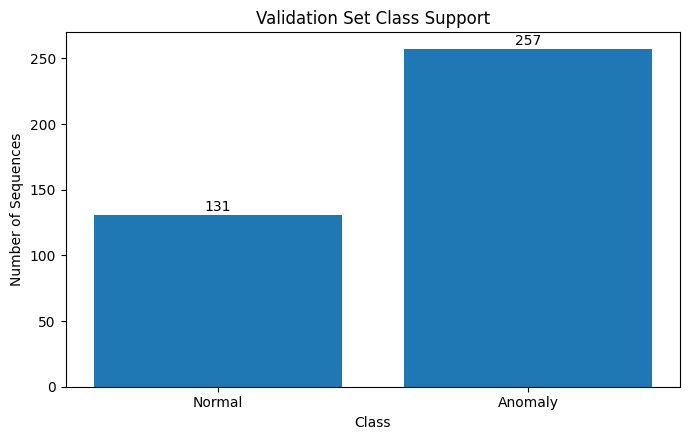

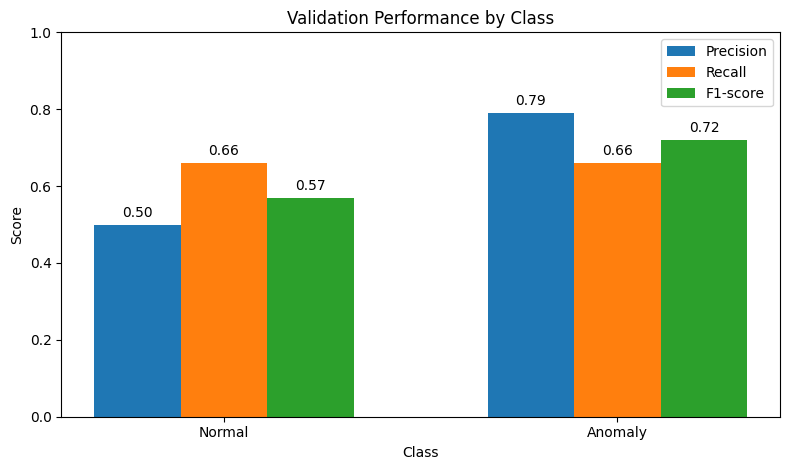

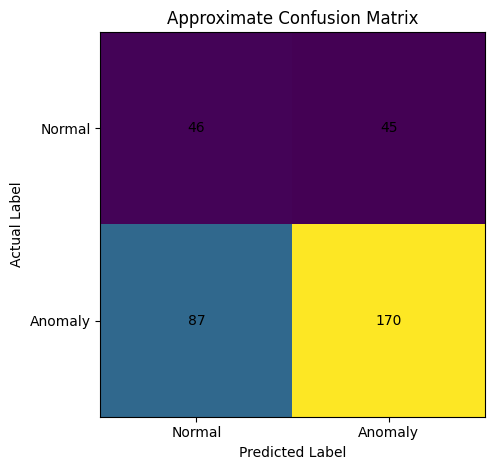

In [1]:
# Optional: recreate the figures from the saved validation report values

import matplotlib.pyplot as plt
import numpy as np

classes = ["Normal", "Anomaly"]
support = [131, 257]
precision = [0.50, 0.79]
recall = [0.66, 0.66]
f1 = [0.57, 0.72]

# Approximate confusion matrix reconstructed from rounded metrics
cm = np.array([[46, 45],
               [87, 170]])

# Figure 1: class support
plt.figure(figsize=(7, 4.5))
plt.bar(classes, support)
plt.title("Validation Set Class Support")
plt.ylabel("Number of Sequences")
plt.xlabel("Class")
for i, v in enumerate(support):
    plt.text(i, v + 3, str(v), ha="center")
plt.tight_layout()
plt.show()

# Figure 2: performance metrics
x = np.arange(len(classes))
width = 0.22

plt.figure(figsize=(8, 4.8))
plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")
plt.xticks(x, classes)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.xlabel("Class")
plt.title("Validation Performance by Class")
plt.legend()
for xpos, vals in zip([x - width, x, x + width], [precision, recall, f1]):
    for xx, v in zip(xpos, vals):
        plt.text(xx, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

# Figure 3: approximate confusion matrix
plt.figure(figsize=(5.5, 4.8))
plt.imshow(cm)
plt.title("Approximate Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Normal", "Anomaly"])
plt.yticks([0, 1], ["Normal", "Anomaly"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()

## 14. Discussion

The main strength of this reproduction is that it preserves the full logic of the BTCNLog workflow. The notebook does not stop at feature extraction or clustering. It builds a complete path from raw logs to final anomaly classification. This makes the implementation useful both as an experiment and as an academic explanation of how semi-supervised log anomaly detection can be organized.

At the same time, several components are simplified. The parser is lighter than a full dictionary-based parser, the pseudo-label generation rule is more direct than a probability-based scheme, and the final model is a practical approximation of a research-oriented Bi-TCN design. These choices make the notebook easier to run and understand, but they also limit how closely the results can match a full benchmark implementation.

## 15. Conclusion

This notebook presents a complete reproduction pipeline for semi-supervised log anomaly detection. The workflow begins with raw BGL log messages, applies preprocessing and parsing, generates BERT-based semantic embeddings, builds fixed-length sequences, uses clustering to create pseudo-labels, and trains a bidirectional temporal convolutional model for final classification.

The overall result is a method-focused reproduction that captures the main reasoning behind BTCNLog in a clear and executable form. While some parts are simplified, the notebook successfully demonstrates how semantic modeling, temporal context, and semi-supervised learning can be combined for log anomaly detection.
